**Ryo Satriagung Hidayat**

**09010624015**


**K-Nearest Neighbors (KNN)**

Klasifikasi Jenis Bunga Iris

Dataset ini digunakan untuk mengklasifikasikan jenis bunga iris berdasarkan ukuran sepal dan petal. Model KNN akan menentukan kategori bunga berdasarkan kedekatan data dengan data lainnya.

**1. IMPORT LIBRARY**








In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics


Library digunakan untuk membaca data, membagi dataset, membuat model KNN, dan mengevaluasi hasil.

**2. LOAD DATASET**

In [19]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Dataset dibaca dari file CSV yang sudah di-upload ke Google Colab.

**3. CETAK STRUKTUR DATA**

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Untuk memastikan data tidak kosong dan semua kolom siap digunakan.

**4. CEK NAMA KOLOM**

In [21]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Untuk mengetahui nama kolom agar tidak salah saat menentukan variabel.

**4.5 EDA Visualisasi (countplot + pairplot + korelasi)**

- Distribusi jumlah sampel per spesies

/tmp/ipykernel_10991/1817327133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Species', palette='Set2')


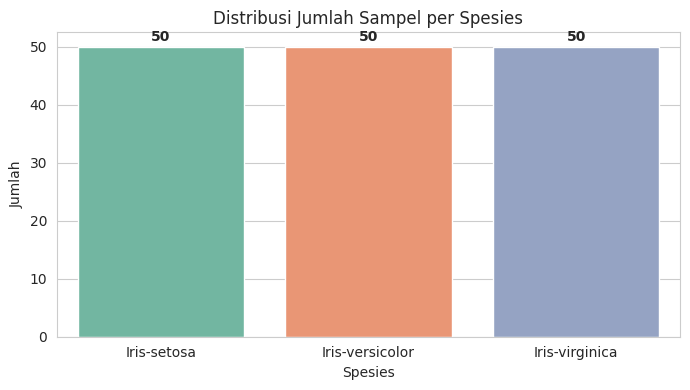

In [31]:
# Distribusi jumlah sampel per spesies
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Species', palette='Set2')
plt.title('Distribusi Jumlah Sampel per Spesies')
plt.xlabel('Spesies')
plt.ylabel('Jumlah')
for i, v in enumerate(df['Species'].value_counts().sort_index()):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

- Pairplot untuk lihat separasi antar kelas

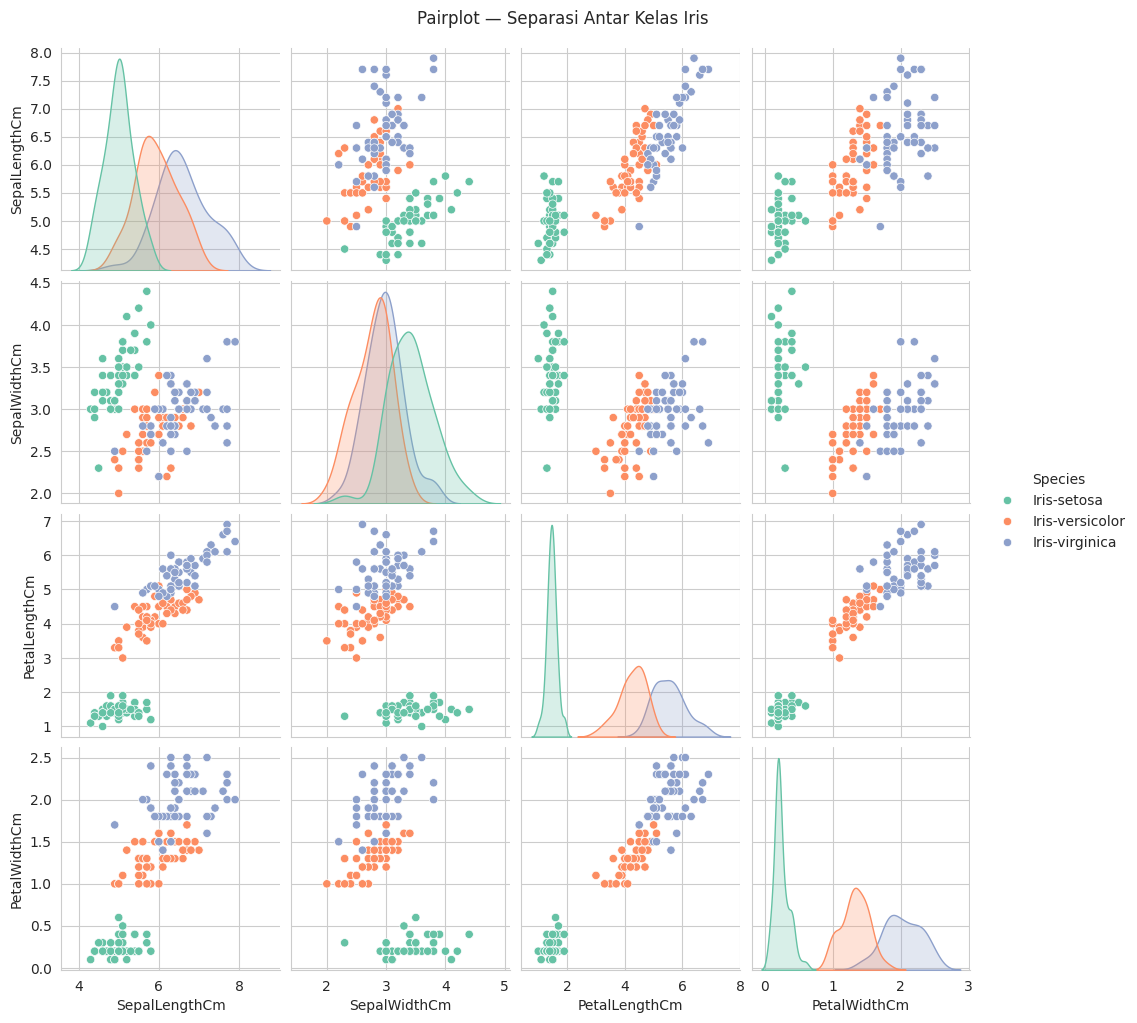

In [32]:
sns.pairplot(df.drop(columns='Id'), hue='Species', palette='Set2', diag_kind='kde')
plt.suptitle('Pairplot — Separasi Antar Kelas Iris', y=1.02)
plt.show()

- Heatmap korelasi antar fitur numerik

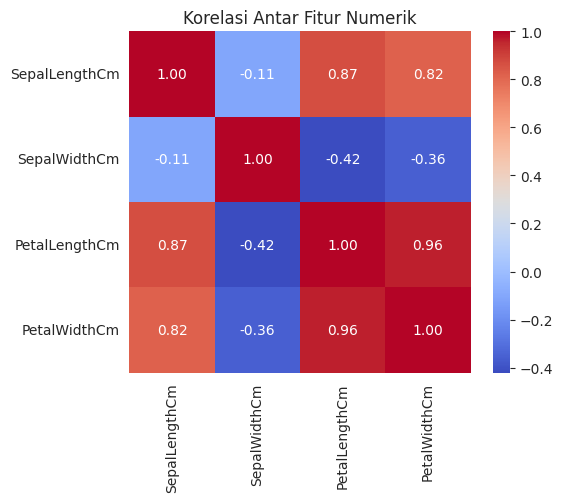

In [33]:
plt.figure(figsize=(6, 5))
corr = df.drop(columns='Id').select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.show()

**5. NORMALISASI & MENENTUKAN VARIABEL x dan y**

In [22]:
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X = fitur (input)

y = label (jenis bunga)

**6. SPLIT DATA train dan test**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Data dibagi menjadi training dan testing agar model bisa diuji.

**6.5 VISUALISASI DISTRIBUSI TRAIN vs TEST**

- Bandingkan proporsi kelas di data train dan test

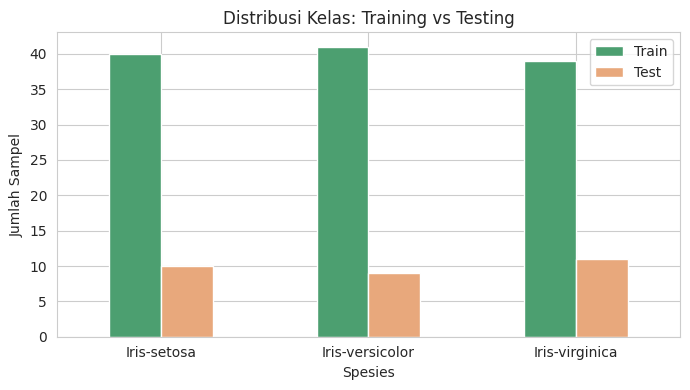

                 Train  Test
Species                     
Iris-setosa         40    10
Iris-versicolor     41     9
Iris-virginica      39    11


In [34]:
train_counts = y_train.value_counts().sort_index()
test_counts  = y_test.value_counts().sort_index()

compare_df = pd.DataFrame({'Train': train_counts, 'Test': test_counts})

compare_df.plot(kind='bar', figsize=(7, 4), color=['#4C9F70', '#E8A87C'])
plt.title('Distribusi Kelas: Training vs Testing')
plt.xlabel('Spesies')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

print(compare_df)

**7. MEMBUAT MODEL KNN**

In [24]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

Model KNN dibuat dengan K = 3, artinya prediksi berdasarkan 3 tetangga terdekat.

**8. PREDIKSI DATA TESTING**

In [25]:
y_pred = model.predict(X_test)

print("Prediksi:", y_pred)
print("Data Asli:", y_test.values)

Prediksi: ['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']
Data Asli: ['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa

Model digunakan untuk memprediksi jenis bunga pada data testing.

**9. EVALUASI MODEL**

In [26]:
print("Akurasi:", metrics.accuracy_score(y_test, y_pred))

Akurasi: 1.0


Mengukur seberapa banyak prediksi yang benar.

**9.5 VISUALISASI CONFUSION MATRIX & CLASSIFICATION REPORT**

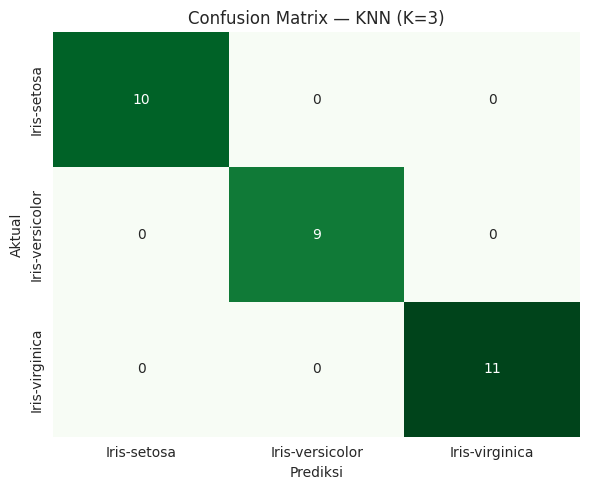

In [35]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, cbar=False)
plt.title('Confusion Matrix — KNN (K=3)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

- Classification Report as Heatmap

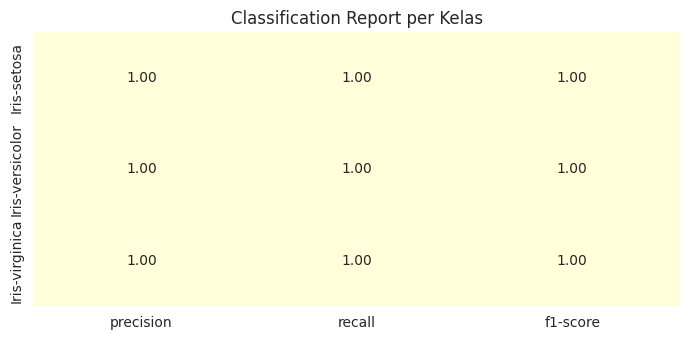

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [36]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose().iloc[:-3, :-1]

plt.figure(figsize=(7, 3.5))
sns.heatmap(report_df, annot=True, cmap='YlGnBu', fmt='.2f', cbar=False)
plt.title('Classification Report per Kelas')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred))

**10. PREDIKSI DATA BARU**

In [27]:
data_baru = [[5.1, 3.5, 1.4, 0.2]]
prediksi = model.predict(data_baru)

print("Jenis bunga:", prediksi[0])

Jenis bunga: Iris-virginica


Digunakan untuk memprediksi jenis bunga baru berdasarkan data input.

**11. PENGEMBANGAN**

In [28]:
print("\nPerbandingan Detail:")
for i in range(len(y_test)):
    print(f"Asli: {y_test.values[i]} | Prediksi: {y_pred[i]}")


Perbandingan Detail:
Asli: Iris-versicolor | Prediksi: Iris-versicolor
Asli: Iris-setosa | Prediksi: Iris-setosa
Asli: Iris-virginica | Prediksi: Iris-virginica
Asli: Iris-versicolor | Prediksi: Iris-versicolor
Asli: Iris-versicolor | Prediksi: Iris-versicolor
Asli: Iris-setosa | Prediksi: Iris-setosa
Asli: Iris-versicolor | Prediksi: Iris-versicolor
Asli: Iris-virginica | Prediksi: Iris-virginica
Asli: Iris-versicolor | Prediksi: Iris-versicolor
Asli: Iris-versicolor | Prediksi: Iris-versicolor
Asli: Iris-virginica | Prediksi: Iris-virginica
Asli: Iris-setosa | Prediksi: Iris-setosa
Asli: Iris-setosa | Prediksi: Iris-setosa
Asli: Iris-setosa | Prediksi: Iris-setosa
Asli: Iris-setosa | Prediksi: Iris-setosa
Asli: Iris-versicolor | Prediksi: Iris-versicolor
Asli: Iris-virginica | Prediksi: Iris-virginica
Asli: Iris-versicolor | Prediksi: Iris-versicolor
Asli: Iris-versicolor | Prediksi: Iris-versicolor
Asli: Iris-virginica | Prediksi: Iris-virginica
Asli: Iris-setosa | Prediksi: Iris-s

Menampilkan perbandingan hasil prediksi dan data asli satu per satu.

**11.5 VISUALISASI PEMILIHAN K OPTIMAL & DECISION BOUNDARY**

- Cari K optimal — train vs test accuracy

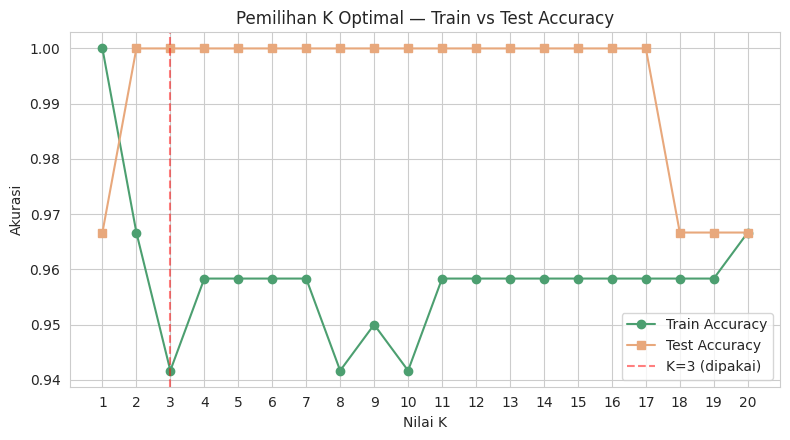

In [37]:
k_range = range(1, 21)
train_acc, test_acc = [], []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    train_acc.append(knn_temp.score(X_train, y_train))
    test_acc.append(knn_temp.score(X_test, y_test))

plt.figure(figsize=(8, 4.5))
plt.plot(k_range, train_acc, 'o-', label='Train Accuracy', color='#4C9F70')
plt.plot(k_range, test_acc, 's-', label='Test Accuracy', color='#E8A87C')
plt.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='K=3 (dipakai)')
plt.title('Pemilihan K Optimal — Train vs Test Accuracy')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.xticks(k_range)
plt.legend()
plt.tight_layout()
plt.show()

- Decision Boundary pakai 2 fitur paling diskriminatif: PetalLength & PetalWidth

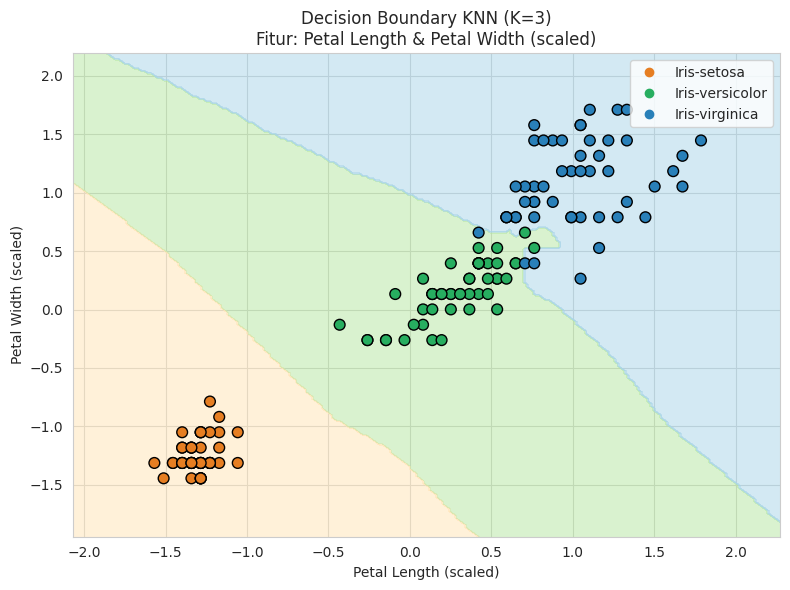

In [38]:
from matplotlib.colors import ListedColormap

X_vis = df[['PetalLengthCm', 'PetalWidthCm']].values
y_vis = pd.Categorical(y).codes
X_vis_scaled = StandardScaler().fit_transform(X_vis)

knn_vis = KNeighborsClassifier(n_neighbors=3)
knn_vis.fit(X_vis_scaled, y_vis)

x_min, x_max = X_vis_scaled[:, 0].min() - 0.5, X_vis_scaled[:, 0].max() + 0.5
y_min, y_max = X_vis_scaled[:, 1].min() - 0.5, X_vis_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_bg = ListedColormap(['#FFE4B5', '#B5E7A0', '#A8D5E8'])
cmap_pt = ListedColormap(['#E67E22', '#27AE60', '#2980B9'])

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.5)
scatter = plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1],
                      c=y_vis, cmap=cmap_pt, edgecolor='k', s=60)
plt.title('Decision Boundary KNN (K=3)\nFitur: Petal Length & Petal Width (scaled)')
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(pd.Categorical(y).categories))
plt.tight_layout()
plt.show()

**12. ANALISIS**

Berdasarkan visualisasi EDA, dataset Iris memiliki distribusi kelas yang seimbang dengan 50 sampel per spesies. Fitur Petal Length dan Petal Width terbukti paling diskriminatif berdasarkan heatmap korelasi dan pairplot, di mana Iris-setosa terpisah jelas dari dua kelas lainnya.
Model KNN dengan K=3 menghasilkan akurasi sempurna (1.0) pada data testing, yang dapat dilihat dari confusion matrix tanpa kesalahan prediksi. Namun, akurasi tinggi ini juga didukung oleh karakteristik dataset yang relatif mudah dipisahkan, sebagaimana ditunjukkan oleh grafik pemilihan K yang menunjukkan akurasi stabil tinggi untuk berbagai nilai K.
Visualisasi decision boundary memperlihatkan bagaimana KNN membagi ruang fitur menjadi tiga region yang sesuai dengan tiga kelas target.